# **Latihan 1**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
import pandas as pd

# Membuat dataset langsung dari tabel yang ada di soal
data = {
    "Temperatur_Udara-C": [10,25,15,20,18,20,22,24],
    "Kecepatan_Angin-km/jam": [0,0,5,3,7,10,5,6],
    "Klasifikasi_Marry": ["Dingin","Panas","Dingin","Panas","Dingin","Dingin","Panas","Panas"],
    "Suhu": [36,81,1,16,4,16,36,64],
    "Angin": [9,9,4,0,16,49,9,9],
    "Jarak": [6.708203932,9.486832981,2.236067977,4.0,4.472135955,8.062257748,6.32455532,8.544003745]
}

df = pd.DataFrame(data)
df

,Temperatur_Udara-C,Kecepatan_Angin-km/jam,Klasifikasi_Marry,Suhu,Angin,Jarak
0,10,0,Dingin,36,9,6.708204
1,25,0,Panas,81,9,9.486833
2,15,5,Dingin,1,4,2.236068
3,20,3,Panas,16,0,4.000000
4,18,7,Dingin,4,16,4.472136
5,20,10,Dingin,16,49,8.062258
6,22,5,Panas,36,9,6.324555
7,24,6,Panas,64,9,8.544004


In [ ]:
# Encode Label
le = LabelEncoder()
df["Klasifikasi_enc"] = le.fit_transform(df["Klasifikasi_Marry"])

In [ ]:
# Memisahkan Fitur dan Target
X = df[["Temperatur_Udara-C", "Kecepatan_Angin-km/jam"]]
y = df["Klasifikasi_enc"]

In [ ]:
# Menormalisasi
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42)

In [ ]:
# Mencari K Terbaik (Akurasi Tertinggi)
akurasi_list = []
K_range = range(1, 7)         # Hanya Sampai 6

for K in K_range:
    model = KNeighborsClassifier(n_neighbors=K)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    akurasi_list.append(accuracy_score(y_test, pred))

In [ ]:
# K Terbaik
k_terbaik = K_range[np.argmax(akurasi_list)]
print("K Terbaik Berdasarkan Akurasi =", k_terbaik)

K Terbaik Berdasarkan Akurasi = 1


In [ ]:
# Train Final Model
model_final = KNeighborsClassifier(n_neighbors=k_terbaik)
model_final.fit(X_scaled, y)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
# Data Test Prediksi
data_test = pd.DataFrame({
    "Temperatur_Udara-C": [16],
    "Kecepatan_Angin-km/jam": [3]
})

data_test_scaled = sc.transform(data_test)
prediksi = model_final.predict(data_test_scaled)
hasil = le.inverse_transform(prediksi)[0]

print("\nPersepsi Marry Untuk Suhu 16C dan Angin 3 km/jam Adalah:", hasil)


Persepsi Marry Untuk Suhu 16C dan Angin 3 km/jam Adalah: Dingin


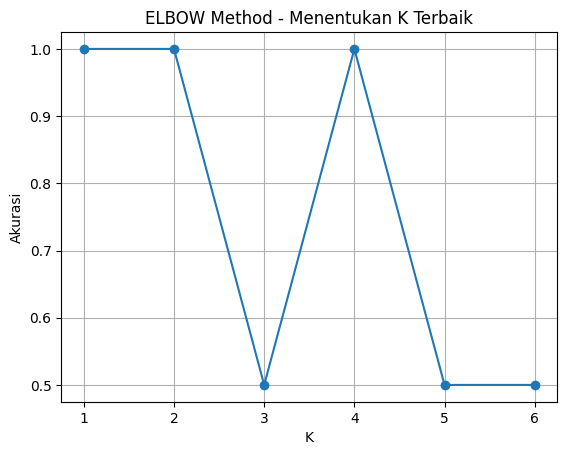

In [ ]:
# Grafik ELBOW
plt.plot(K_range, akurasi_list, marker='o')
plt.title("ELBOW Method - Menentukan K Terbaik")
plt.xlabel("K")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()